In [17]:
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine


In [2]:
X, y = make_moons(n_samples=500,noise=0.05,random_state=42)

df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
print("First 10 Rows:")
print(df.head(10))

print("\nShape of Dataset:")
print(df.shape)

First 10 Rows:
   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959

Shape of Dataset:
(500, 2)


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

X_scaled = pd.DataFrame(X_scaled,columns=["Feature1", "Feature2"])

print("First 5 Rows of Scaled Data:")
print(X_scaled.head())

First 5 Rows of Scaled Data:
   Feature1  Feature2
0  0.375125 -1.403679
1  0.226815  1.135628
2  0.595442 -1.493710
3 -0.944918  1.409748
4 -0.243115  1.618062


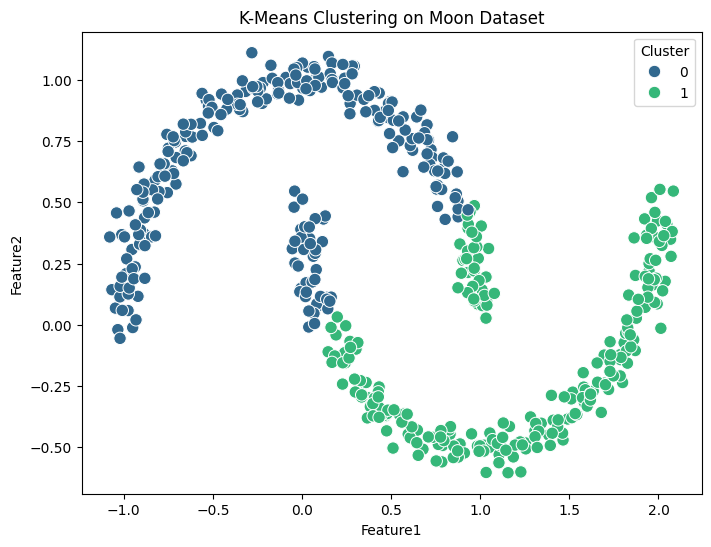

In [7]:
kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = clusters

plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="Feature1",y="Feature2",hue="kmeans_cluster",palette="viridis",s=80)

plt.title("K-Means Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend(title="Cluster")

plt.show()

Cluster Counts:
dbscan_cluster
0    250
1    250
Name: count, dtype: int64


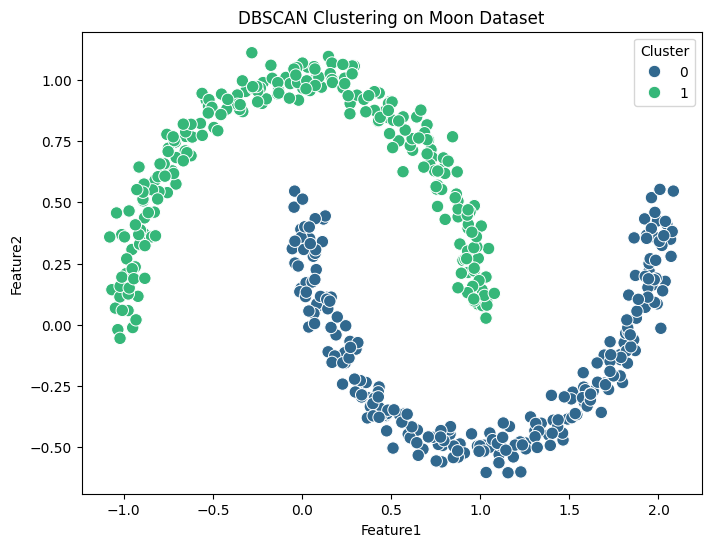

In [9]:
dbscan = DBSCAN(eps=0.3,min_samples=5)

dbscan_clusters = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = dbscan_clusters

print("Cluster Counts:")
print(df["dbscan_cluster"].value_counts().sort_index())

plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="Feature1",y="Feature2",hue="dbscan_cluster",palette="viridis",s=80)

plt.title("DBSCAN Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend(title="Cluster")

plt.show()

In [10]:
eps_values = [0.2, 0.3, 0.4, 0.5]

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise_points = list(labels).count(-1)

    results.append([eps, n_clusters, noise_points])

results_df = pd.DataFrame(
    results,
    columns=["eps", "Number of Clusters", "Noise Points"]
)

print(results_df)

print("\nObservation:")
print("For the make_moons dataset, eps = 0.3 generally provides the best balance")
print("between correctly identifying the two moon-shaped clusters and minimizing noise.")

   eps  Number of Clusters  Noise Points
0  0.2                   2             0
1  0.3                   2             0
2  0.4                   2             0
3  0.5                   2             0

Observation:
For the make_moons dataset, eps = 0.3 generally provides the best balance
between correctly identifying the two moon-shaped clusters and minimizing noise.


In [11]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=500,n_features=6,centers=4,cluster_std=1.5,random_state=42)

df = pd.DataFrame(
    X,
    columns=["Feature1", "Feature2", "Feature3", "Feature4", "Feature5", "Feature6"]
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df.columns
)
print("First 5 Rows of Scaled Data:")
print(X_scaled.head())

print("\nShape of Dataset:")
print(X_scaled.shape)

First 5 Rows of Scaled Data:
   Feature1  Feature2  Feature3  Feature4  Feature5  Feature6
0 -1.052513  0.719083  0.350444  0.989657 -1.619597  1.414499
1  0.140795 -1.040620  0.841574 -0.857108  0.458731 -0.556293
2 -0.143302  1.113049  0.785668  0.686643 -0.153543 -1.524124
3 -1.093345  0.925894 -0.009533  1.108893 -1.371680  1.210841
4 -1.541419  0.736345  0.562503  1.015382 -0.375990  1.392803

Shape of Dataset:
(500, 6)


In [14]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = y

print("PCA DataFrame:")
print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

PCA DataFrame:
        PC1       PC2  Cluster
0  2.369765  1.259783        1
1 -0.943367 -0.829777        3
2  0.982191 -1.768556        0
3  2.265086  1.190377        1
4  2.142129  0.840804        1

Explained Variance Ratio:
[0.64327878 0.21039738]


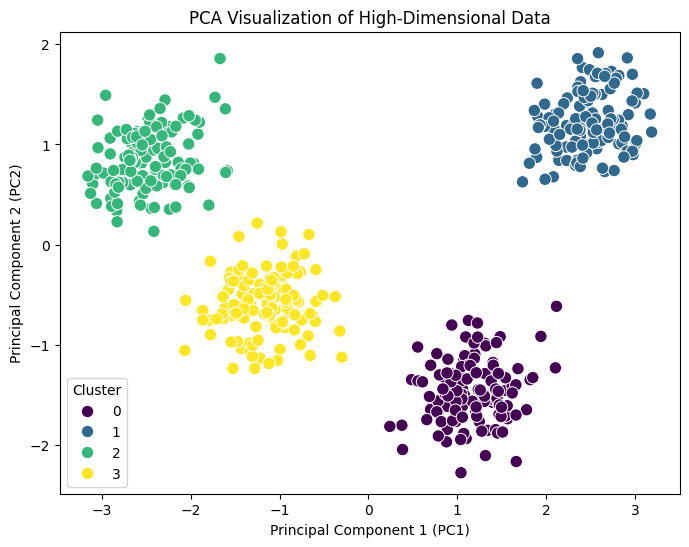

Explained Variance Ratio:
[0.64327878 0.21039738]

Total Variance Retained:
0.853676159895889


In [15]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="viridis",s=80)

plt.title("PCA Visualization of High-Dimensional Data")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Cluster")

plt.show()

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Retained:")
print(pca.explained_variance_ratio_.sum())

First 5 Rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0    

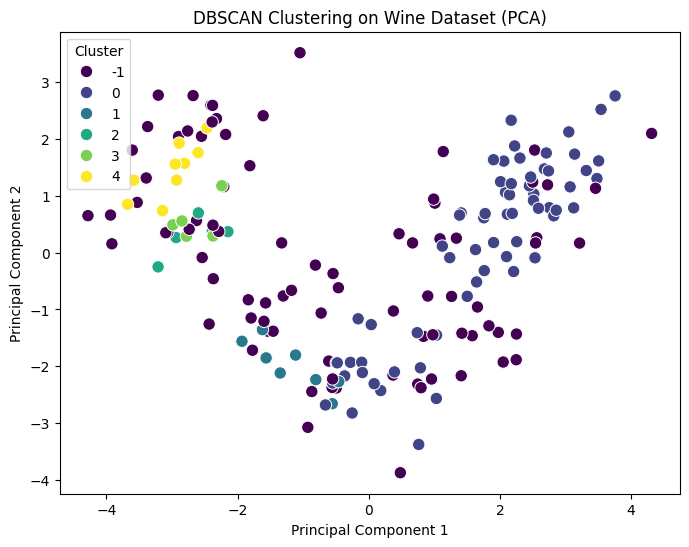


Explained Variance Ratio:
[0.36198848 0.1920749 ]

Total Explained Variance:
0.5540633835693526


In [18]:
wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

print("First 5 Rows:")
print(df.head())

print("\nShape:")
print(df.shape)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = clusters

print("\nCluster Counts:")
print(df["DBSCAN_Cluster"].value_counts())


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="viridis",s=80)

plt.title("DBSCAN Clustering on Wine Dataset (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())